# Поведение агентов

Один жадный эпизод обученных агентов против того же мира под случайными агентами (одинаковый сид): каждая панель показывает, что дают выученные политики.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "training" / "config.py").exists():
            return candidate
    raise RuntimeError("project root not found (training/config.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.config import DELIVERY_AGENTS, N_DELIVERY_WINDOWS, FruitKey
from core.world.fruits import get_params
from env.training_env import ColdChainTrainingEnv
from training.config import COMPARE_SEED, build_agents, env_config, load_agents
from training.marl.agents import RandomAgent

AGENTS = ["temperature", "routing", "spoilage", "inventory", *DELIVERY_AGENTS]
SEED = COMPARE_SEED
KIND_ORDER = ["farm", "hub", "dc", "retail"]
KIND_COLOR = {"farm": "tab:green", "hub": "tab:blue", "dc": "tab:orange",
              "retail": "tab:red"}

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Запись эпизода: обученные и случайные (один сид)

In [2]:
def record_episode(env, agents, learners):
    obs, _ = env.reset()
    s0 = env._state
    meta = {
        "fruit": s0.shipment.fruit_type.value,
        "source": s0.shipment.current_node,
        "target": s0.shipment.target_node,
        "weather": s0.ambient_weather.value,
        "ambient_temp_c": s0.ambient_temp_c,
    }
    path = [s0.shipment.current_node]
    rows = []
    done = False
    while not done:
        actions = {a: agents[a].act(obs[a], explore=False) for a in agents}
        obs, rewards, terminated, truncated, _ = env.step(actions)
        s = env._state.shipment
        row = {
            "tick": env._state.tick,
            "desired": s.desired_temperature_c,
            "sensor": s.sensor_temperature_c,
            "spoilage_risk": s.spoilage_risk,
            "route_travel_time": env._state.route_travel_time,
            "route_emissions": env._state.route_emissions,
            "spoilage_prediction": env._state.spoilage_prediction,
            "inventory_level": env._state.inventory_level,
            "inventory_order": env._state.inventory_order,
            "unmet_demand": env._state.unmet_demand,
        }
        for i, v in enumerate(env._state.vehicles):
            row[f"slot_{i}"] = v.chosen_slot
            row[f"conflict_{i}"] = float(v.conflict)
        for a in learners:
            row[f"reward_{a}"] = rewards[a]
        rows.append(row)
        path.append(s.current_node)
        done = terminated["__all__"] or truncated["__all__"]
    return pd.DataFrame(rows), path, meta


env = ColdChainTrainingEnv(env_config(SEED, AGENTS))
agents = load_agents(env, AGENTS)
df, path, meta = record_episode(env, agents, AGENTS)
graph = env._state.graph
vehicles = env._state.vehicles
max_steps = env._state.max_steps

env_r = ColdChainTrainingEnv(env_config(SEED, AGENTS))
agents_r = build_agents(env_r, AGENTS)
for a in AGENTS:
    agents_r[a] = RandomAgent(env_r.action_space(a))
df_r, path_r, _ = record_episode(env_r, agents_r, AGENTS)

fruit = get_params(FruitKey(meta["fruit"]))
delivered = path[-1] == meta["target"]
delivered_r = path_r[-1] == meta["target"]

print(f"{meta['fruit']}: {meta['source']} -> {meta['target']} "
      f"({meta['weather']}, ambient {meta['ambient_temp_c']:.1f} C)")
print(f"trained: {len(df)} steps, delivered={delivered}  |  "
      f"random: {len(df_r)} steps, delivered={delivered_r}")

banana: farm_1 -> retail_1 (sunny, ambient 27.9 C)
trained: 3 steps, delivered=True  |  random: 20 steps, delivered=False


## Контроль температуры

Обученный агент держит сенсор в идеальной полосе фрукта; случайные уставки дают дрейф и разгоняют риск порчи.

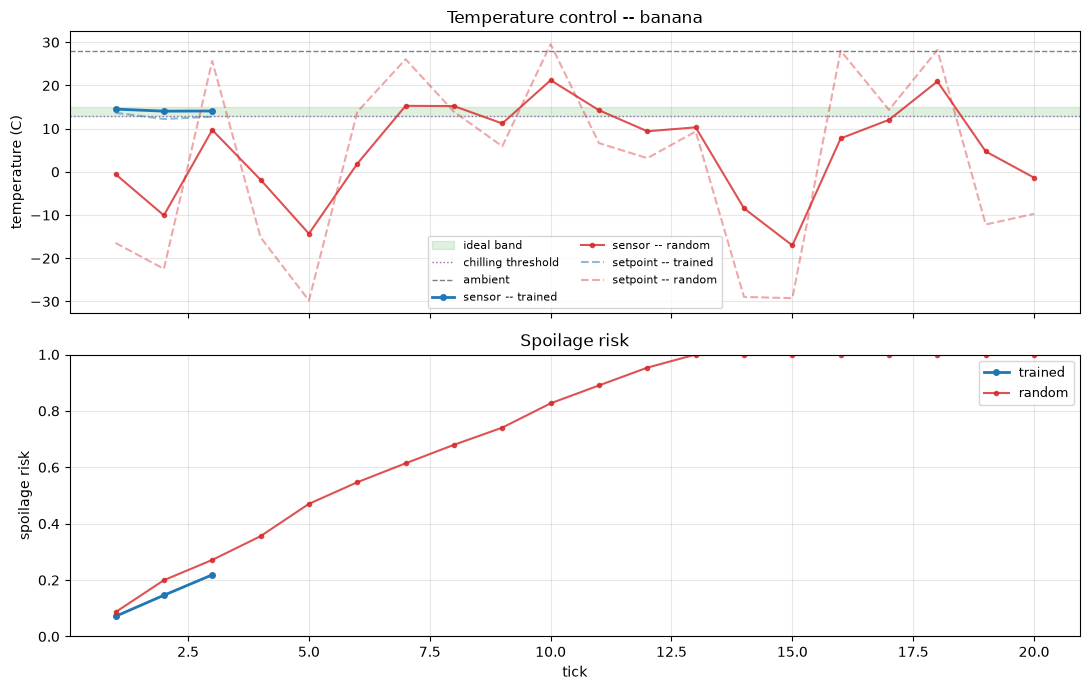

In [3]:
fig, (ax_t, ax_s) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax_t.axhspan(fruit.optimal_temp_low_c, fruit.optimal_temp_high_c,
             color="tab:green", alpha=0.15, label="ideal band")
if fruit.chilling_injury_threshold_c is not None:
    ax_t.axhline(fruit.chilling_injury_threshold_c, color="tab:purple", ls=":",
                 lw=1, label="chilling threshold")
ax_t.axhline(meta["ambient_temp_c"], color="tab:gray", ls="--", lw=1, label="ambient")
ax_t.plot(df["tick"], df["sensor"], marker="o", ms=4, lw=2, color="tab:blue",
          label="sensor -- trained")
ax_t.plot(df_r["tick"], df_r["sensor"], marker="o", ms=3, lw=1.5, alpha=0.8,
          color="tab:red", label="sensor -- random")
ax_t.plot(df["tick"], df["desired"], ls="--", color="tab:blue", alpha=0.5,
          label="setpoint -- trained")
ax_t.plot(df_r["tick"], df_r["desired"], ls="--", color="tab:red", alpha=0.4,
          label="setpoint -- random")
ax_t.set(ylabel="temperature (C)", title=f"Temperature control -- {meta['fruit']}")
ax_t.legend(fontsize=8, ncol=2)

ax_s.plot(df["tick"], df["spoilage_risk"], marker="o", ms=4, lw=2, color="tab:blue",
          label="trained")
ax_s.plot(df_r["tick"], df_r["spoilage_risk"], marker="o", ms=3, lw=1.5, alpha=0.8,
          color="tab:red", label="random")
ax_s.set(xlabel="tick", ylabel="spoilage risk", ylim=(0, 1), title="Spoilage risk")
ax_s.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Маршрут

Обученный DQN идёт к цели. Красное — фактические переходы (пронумерованы), зелёный пунктир — кратчайший по времени, оранжевый точечный — кратчайший по стоимости Алг. 1. Агент оптимизирует стоимость Алг. 1 (время + выбросы + риск порчи + бонус доставки), поэтому его маршрут не обязан совпадать с кратчайшим по времени.

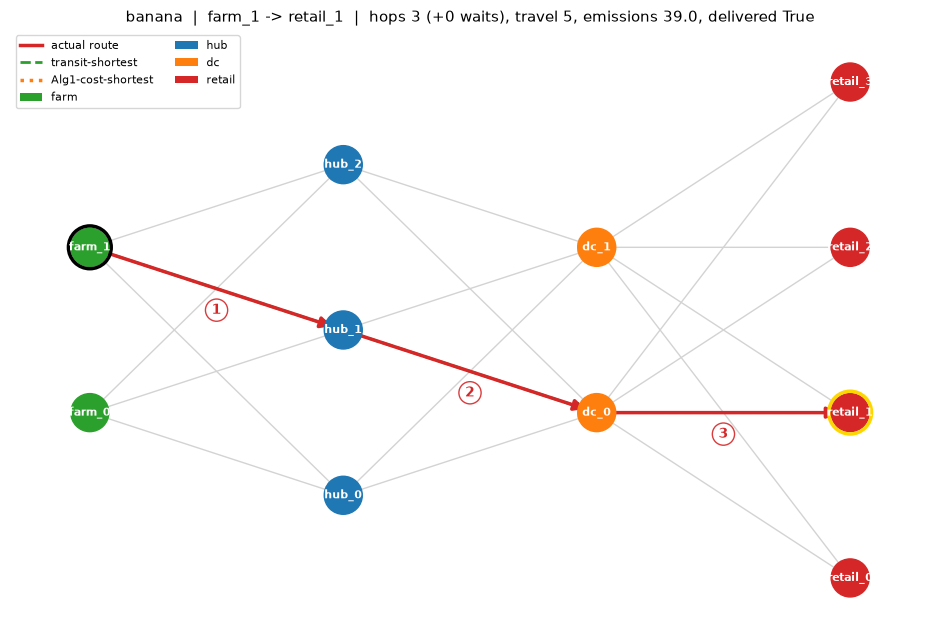

In [4]:
from env.training_env import ROUTE_EMISSIONS_WEIGHT, ROUTE_TIME_WEIGHT


def alg1_edge_cost(u, v, d):
    return (ROUTE_TIME_WEIGHT * d["base_transit_time"]
            + ROUTE_EMISSIONS_WEIGHT * d["base_emissions"])


def layered_pos(graph):
    pos = {}
    for x, kind in enumerate(KIND_ORDER):
        nodes = [n for n, d in graph.nodes(data=True) if d["kind"] == kind]
        for i, n in enumerate(nodes):
            pos[n] = (float(x), i - (len(nodes) - 1) / 2)
    return pos


pos = layered_pos(graph)
fig, ax = plt.subplots(figsize=(9.5, 6.5))

transport = [(u, v) for u, v, d in graph.edges(data=True) if not d["wait"]]
nx.draw_networkx_edges(graph, pos, edgelist=transport, edge_color="lightgray",
                       width=1, ax=ax)
nx.draw_networkx_nodes(graph, pos, node_size=750, ax=ax,
                       node_color=[KIND_COLOR[graph.nodes[n]["kind"]] for n in graph.nodes])
nx.draw_networkx_labels(graph, pos, font_size=8, font_weight="bold",
                        font_color="white", ax=ax)

t_short = nx.shortest_path(graph, meta["source"], meta["target"],
                           weight="base_transit_time")
nx.draw_networkx_edges(graph, pos, edgelist=list(zip(t_short, t_short[1:])),
                       edge_color="tab:green", style="dashed", width=2, ax=ax)
c_short = nx.shortest_path(graph, meta["source"], meta["target"], weight=alg1_edge_cost)
if c_short != t_short:
    nx.draw_networkx_edges(graph, pos, edgelist=list(zip(c_short, c_short[1:])),
                           edge_color="tab:orange", style="dotted", width=2.5, ax=ax)

hops = [(a, b) for a, b in zip(path, path[1:]) if a != b]
nx.draw_networkx_edges(graph, pos, edgelist=hops, edge_color="tab:red", width=2.5,
                       arrowsize=16, ax=ax)
for order, (a, b) in enumerate(hops, start=1):
    x, y = (pos[a][0] + pos[b][0]) / 2, (pos[a][1] + pos[b][1]) / 2
    ax.text(x, y - 0.13, str(order), color="tab:red", fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="circle", fc="white", ec="tab:red", alpha=0.9))

for node, ring in [(meta["source"], "black"), (meta["target"], "gold")]:
    nx.draw_networkx_nodes(graph, pos, nodelist=[node], node_color="none",
                           edgecolors=ring, linewidths=2.5, node_size=950, ax=ax)

legend = [
    Line2D([0], [0], color="tab:red", lw=2.5, label="actual route"),
    Line2D([0], [0], color="tab:green", lw=2, ls="dashed", label="transit-shortest"),
    Line2D([0], [0], color="tab:orange", lw=2.5, ls="dotted", label="Alg1-cost-shortest"),
    *(Patch(fc=KIND_COLOR[k], label=k) for k in KIND_ORDER),
]
ax.legend(handles=legend, loc="upper left", fontsize=8, ncol=2)
waits = len(path) - 1 - len(hops)
ax.set_title(
    f"{meta['fruit']}  |  {meta['source']} -> {meta['target']}  |  "
    f"hops {len(hops)} (+{waits} waits), travel {df['route_travel_time'].iloc[-1]:.0f}, "
    f"emissions {df['route_emissions'].iloc[-1]:.1f}, delivered {delivered}",
    fontsize=11,
)
ax.axis("off")
fig.tight_layout()
plt.show()

## Прогноз порчи

Обученный предиктор следует за риском Аррениуса; случайный — шум вокруг 0.5.

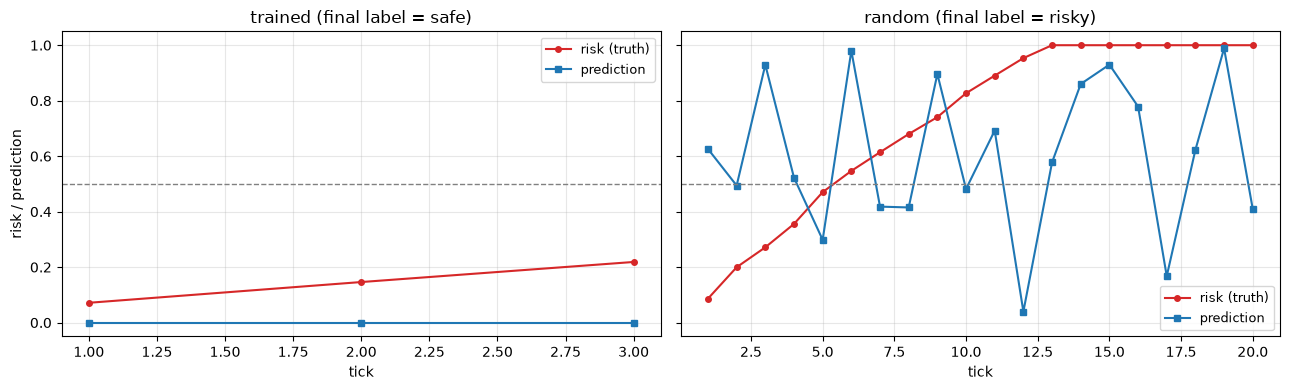

In [5]:
from core.world.spoilage import risk_to_label

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, d, tag in ((axes[0], df, "trained"), (axes[1], df_r, "random")):
    ax.plot(d["tick"], d["spoilage_risk"], marker="o", ms=4, color="tab:red",
            label="risk (truth)")
    ax.plot(d["tick"], d["spoilage_prediction"], marker="s", ms=4, color="tab:blue",
            label="prediction")
    ax.axhline(0.5, ls="--", color="gray", lw=1)
    label = risk_to_label(d["spoilage_risk"].iloc[-1])
    ax.set(xlabel="tick", ylim=(-0.05, 1.05),
           title=f"{tag} (final label = {'risky' if label else 'safe'})")
    ax.legend(fontsize=9)
axes[0].set_ylabel("risk / prediction")
fig.tight_layout()
plt.show()

## Управление запасами

Стоимость Алг. 4 штрафует хранение, заказы и запас, взвешенный порчей. Обученный держит уровень экономным без накопления неудовлетворённого спроса; случайный пере- и недозаказывает.

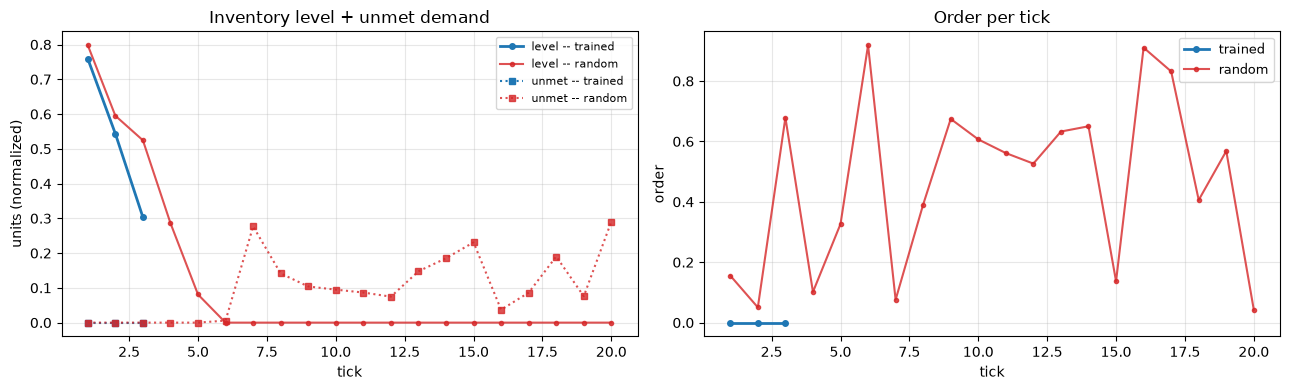

In [6]:
fig, (ax_l, ax_o) = plt.subplots(1, 2, figsize=(13, 4))
ax_l.plot(df["tick"], df["inventory_level"], marker="o", ms=4, lw=2,
          color="tab:blue", label="level -- trained")
ax_l.plot(df_r["tick"], df_r["inventory_level"], marker="o", ms=3, lw=1.5,
          alpha=0.8, color="tab:red", label="level -- random")
ax_l.plot(df["tick"], df["unmet_demand"], marker="s", ms=4, ls=":",
          color="tab:blue", label="unmet -- trained")
ax_l.plot(df_r["tick"], df_r["unmet_demand"], marker="s", ms=4, ls=":",
          alpha=0.8, color="tab:red", label="unmet -- random")
ax_l.set(xlabel="tick", ylabel="units (normalized)",
         title="Inventory level + unmet demand")
ax_l.legend(fontsize=8)

ax_o.plot(df["tick"], df["inventory_order"], marker="o", ms=4, lw=2,
          color="tab:blue", label="trained")
ax_o.plot(df_r["tick"], df_r["inventory_order"], marker="o", ms=3, lw=1.5,
          alpha=0.8, color="tab:red", label="random")
ax_o.set(xlabel="tick", ylabel="order", title="Order per tick")
ax_o.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Слоты доставки

Машины должны разойтись по слотам (конфликт → ρ), дедлайн слота — покрывать транзит маршрута. Обученные: разные стабильные слоты. Случайные: коллизии (красные ×).

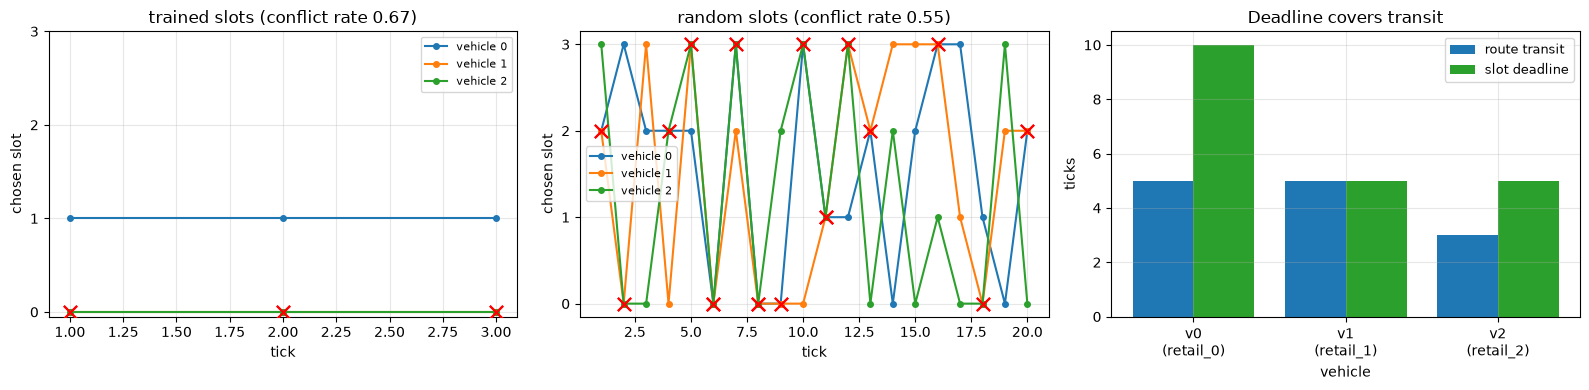

In [7]:
n_v = len(vehicles)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, d, tag in ((axes[0], df, "trained"), (axes[1], df_r, "random")):
    for i in range(n_v):
        ax.plot(d["tick"], d[f"slot_{i}"], marker="o", ms=4, label=f"vehicle {i}")
        conf = d[d[f"conflict_{i}"] > 0]
        ax.scatter(conf["tick"], conf[f"slot_{i}"], marker="x", s=90, color="red",
                   zorder=3)
    conf_rate = d[[f"conflict_{i}" for i in range(n_v)]].to_numpy().mean()
    ax.set(xlabel="tick", ylabel="chosen slot", yticks=range(N_DELIVERY_WINDOWS),
           title=f"{tag} slots (conflict rate {conf_rate:.2f})")
    ax.legend(fontsize=8)

slots_final = [df[f"slot_{i}"].iloc[-1] for i in range(n_v)]
deadlines = [(s + 1) / N_DELIVERY_WINDOWS * max_steps for s in slots_final]
transits = [v.route_transit for v in vehicles]
x = np.arange(n_v)
axes[2].bar(x - 0.2, transits, 0.4, label="route transit", color="tab:blue")
axes[2].bar(x + 0.2, deadlines, 0.4, label="slot deadline", color="tab:green")
axes[2].set(xlabel="vehicle", ylabel="ticks", title="Deadline covers transit",
            xticks=x,
            xticklabels=[f"v{i}\n({v.assigned_node})" for i, v in enumerate(vehicles)])
axes[2].legend(fontsize=9)
fig.tight_layout()
plt.show()

## Тест координации: две машины на одном маршруте

Худший случай для MADDPG-группы: машине 1 принудительно даётся маршрут машины 0, наблюдения совпадают во всём, кроме `vehicle_id`. Без этого признака группа схлопывалась в общий слот (conflict rate 0.68). Ожидание: близнецы берут разные слоты, ноль конфликтов, оба дедлайна покрывают одинаковый транзит.

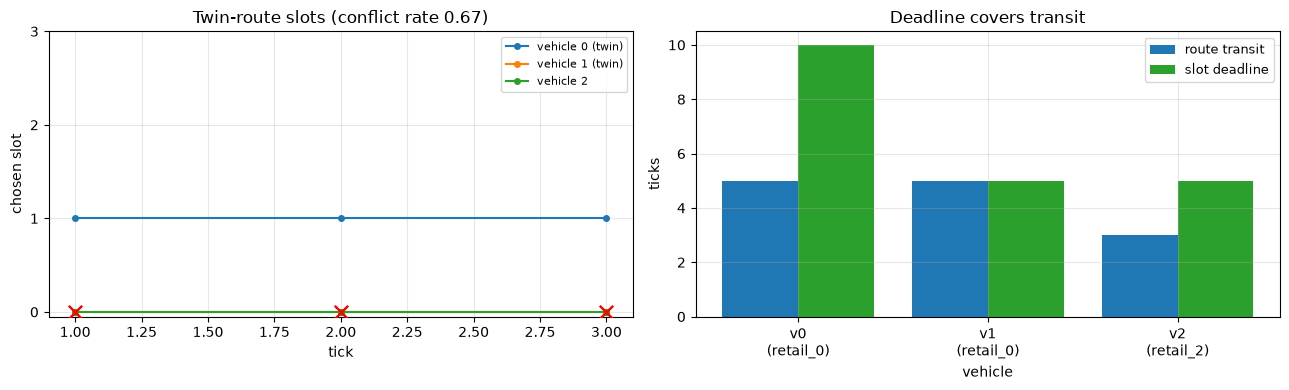

twin slots: v0=1, v1=0  |  distinct=True  |  conflict rate 0.67


In [8]:
from core.interfaces.observations import delivery_obs

env_c = ColdChainTrainingEnv(env_config(SEED, AGENTS))
obs, _ = env_c.reset()
state_c = env_c._state
src, dup = state_c.vehicles[0], state_c.vehicles[1]
dup.assigned_node = src.assigned_node
dup.route_transit = src.route_transit
dup.route_emissions = src.route_emissions
dup.sla_window_ticks = src.sla_window_ticks
for i, name in enumerate(DELIVERY_AGENTS):
    obs[name] = delivery_obs(state_c, i)

rows = []
done = False
while not done:
    actions = {a: agents[a].act(obs[a], explore=False) for a in agents}
    obs, _, term, trunc, _ = env_c.step(actions)
    row = {"tick": env_c._state.tick}
    for i, v in enumerate(env_c._state.vehicles):
        row[f"slot_{i}"] = v.chosen_slot
        row[f"conflict_{i}"] = float(v.conflict)
    rows.append(row)
    done = term["__all__"] or trunc["__all__"]
df_c = pd.DataFrame(rows)

vehicles_c = env_c._state.vehicles
n_v = len(vehicles_c)
fig, (ax_s, ax_d) = plt.subplots(1, 2, figsize=(13, 4))
for i in range(n_v):
    twin = " (twin)" if i < 2 else ""
    ax_s.plot(df_c["tick"], df_c[f"slot_{i}"], marker="o", ms=4,
              label=f"vehicle {i}{twin}")
    conf = df_c[df_c[f"conflict_{i}"] > 0]
    ax_s.scatter(conf["tick"], conf[f"slot_{i}"], marker="x", s=90, color="red",
                 zorder=3)
conf_rate = df_c[[f"conflict_{i}" for i in range(n_v)]].to_numpy().mean()
ax_s.set(xlabel="tick", ylabel="chosen slot", yticks=range(N_DELIVERY_WINDOWS),
         title=f"Twin-route slots (conflict rate {conf_rate:.2f})")
ax_s.legend(fontsize=8)

slots_last = [df_c[f"slot_{i}"].iloc[-1] for i in range(n_v)]
deadlines = [(s + 1) / N_DELIVERY_WINDOWS * env_c._state.max_steps for s in slots_last]
transits = [v.route_transit for v in vehicles_c]
x = np.arange(n_v)
ax_d.bar(x - 0.2, transits, 0.4, label="route transit", color="tab:blue")
ax_d.bar(x + 0.2, deadlines, 0.4, label="slot deadline", color="tab:green")
ax_d.set(xlabel="vehicle", ylabel="ticks", title="Deadline covers transit",
         xticks=x,
         xticklabels=[f"v{i}\n({v.assigned_node})" for i, v in enumerate(vehicles_c)])
ax_d.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"twin slots: v0={slots_last[0]}, v1={slots_last[1]}  |  "
      f"distinct={slots_last[0] != slots_last[1]}  |  conflict rate {conf_rate:.2f}")

## Награды

Кумулятивный return по агентам: обученные (сплошная) против случайных (пунктир) на одном мире.

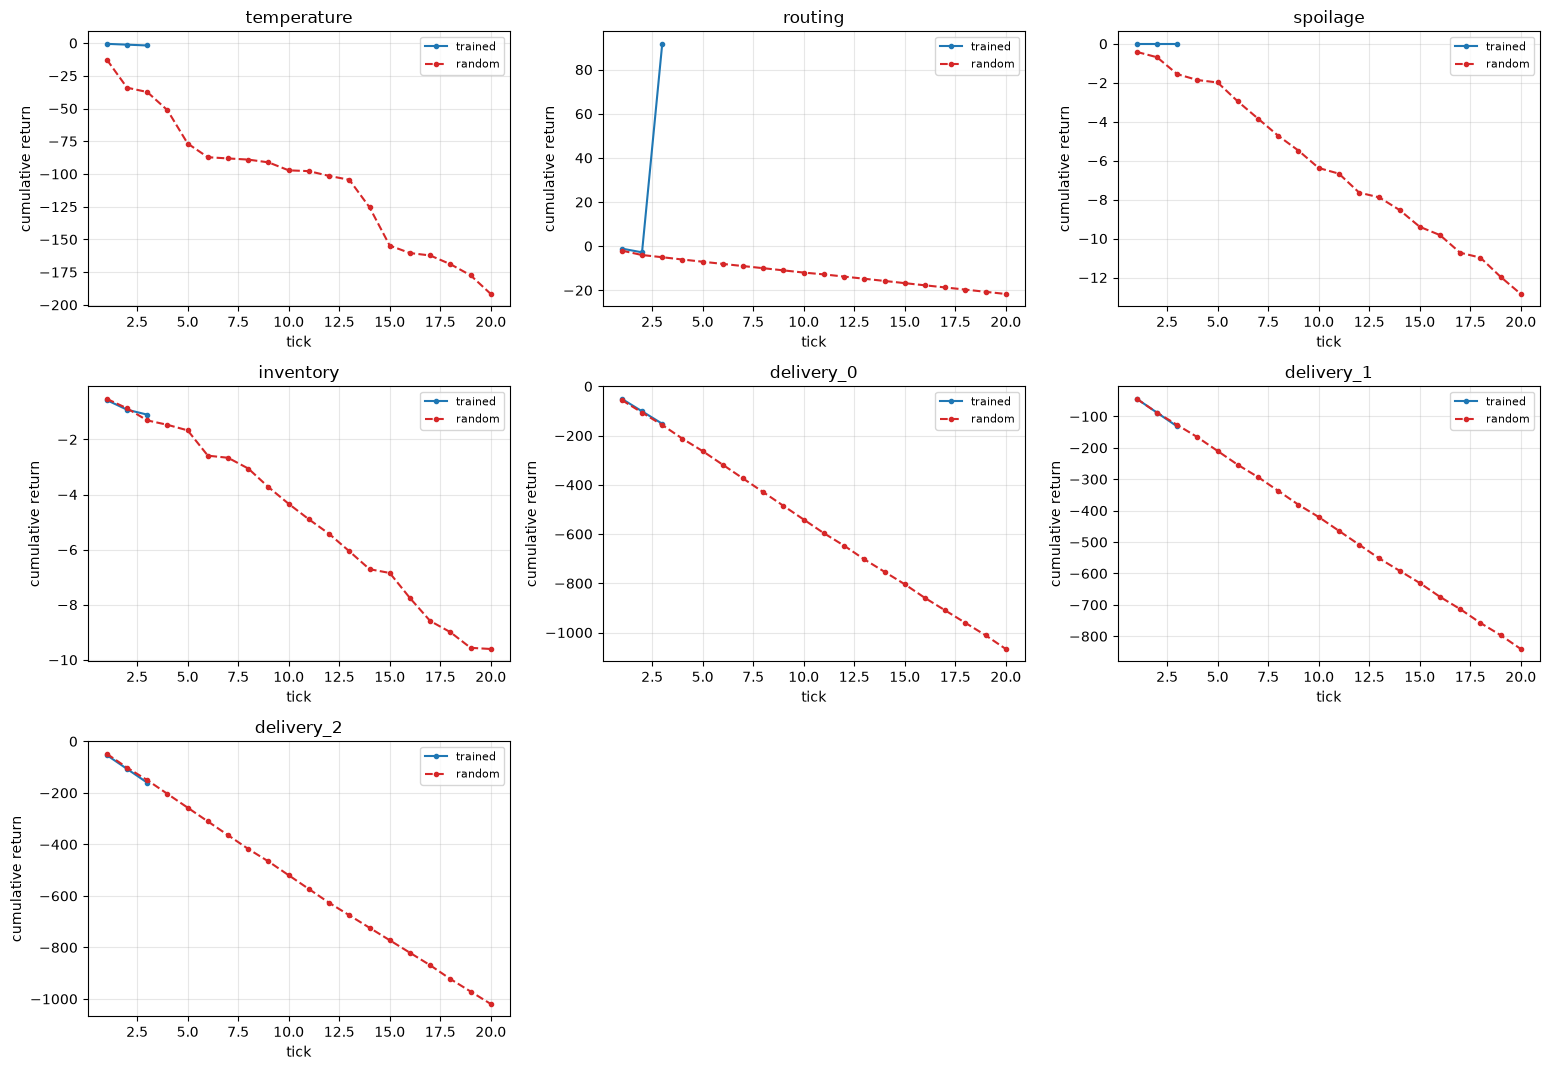

In [9]:
import math

cols = 3
n_rows = math.ceil(len(AGENTS) / cols)
fig, axes = plt.subplots(n_rows, cols, figsize=(5.2 * cols, 3.6 * n_rows),
                         squeeze=False)
for k, a in enumerate(AGENTS):
    ax = axes[k // cols][k % cols]
    col = f"reward_{a}"
    ax.plot(df["tick"], df[col].cumsum(), marker="o", ms=3, color="tab:blue",
            label="trained")
    ax.plot(df_r["tick"], df_r[col].cumsum(), marker="o", ms=3, ls="--",
            color="tab:red", label="random")
    ax.set(xlabel="tick", ylabel="cumulative return", title=a)
    ax.legend(fontsize=8)
for k in range(len(AGENTS), n_rows * cols):
    axes[k // cols][k % cols].axis("off")
fig.tight_layout()
plt.show()